# Options Pricing & Portfolio Optimization via PyTorch Autograd

Textbook quant finance hand-derives five separate Greek formulas (Delta,
Gamma, Vega, Theta, Rho) from the Black-Scholes PDE. This notebook computes
all five from **one** price formula, differentiated by
`torch.autograd.grad` -- the same principle a neural net uses to get every
parameter's gradient from one loss, applied to an options-pricing formula
instead. It also uses gradient ASCENT (not the textbook closed-form matrix
solve) to find a max-Sharpe portfolio, and covers Monte Carlo pricing and
VaR/CVaR risk. Engine: `dgs/financial_math_torch.py`, checked against
closed-form Greeks to 1e-6 and against Black-Scholes within its own Monte
Carlo confidence interval (`tests/test_financial_math_torch.py`).


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import math
import numpy as np
import torch
import matplotlib.pyplot as plt

from dgs import financial_math_torch as fin

print("Setup complete. torch", torch.__version__, "cuda:", torch.cuda.is_available())


Setup complete. torch 2.12.0+cpu cuda: False


## 1. Theory, Step by Step -- What Each Symbol Physically Means

**Step 1**: Under the risk-neutral measure, a stock price follows geometric
Brownian motion: $dS = rS\,dt + \sigma S\,dW$ -- $r$ is the risk-free
drift (no-arbitrage requires discounting at $r$, not the stock's real
expected return), $\sigma$ is volatility (the size of random fluctuations),
$dW$ is a Wiener increment (the source of randomness).

**Step 2**: Solving that SDE gives the terminal price in closed form:
$S_T = S_0\exp\left((r-\sigma^2/2)T + \sigma\sqrt{T}\,Z\right)$,
$Z\sim N(0,1)$ -- this is exact, no time discretization needed, which is
what `monte_carlo_gbm_terminal` uses directly.

**Step 3**: A European call pays $\max(S_T-K, 0)$ at expiry. Its
no-arbitrage price today is the DISCOUNTED, RISK-NEUTRAL expectation of
that payoff: $C = e^{-rT}\,\mathbb E[\max(S_T-K,0)]$. Black-Scholes
evaluates that expectation in closed form:
$$C = S_0 N(d_1) - Ke^{-rT}N(d_2), \qquad
d_1=\frac{\ln(S_0/K)+(r+\sigma^2/2)T}{\sigma\sqrt T},\quad
d_2 = d_1-\sigma\sqrt T$$
$N(\cdot)$ is the standard normal CDF -- physically, $N(d_2)$ is the
risk-neutral probability the option finishes in the money, and $N(d_1)$ is
that probability tilted by how much it finishes in the money (it's also
exactly the option's Delta, which is why the SAME formula returns both).

**Step 4**: The Greeks are just partial derivatives of $C$ with respect to
its inputs ($\partial C/\partial S$ = Delta, $\partial C/\partial\sigma$
= Vega, etc.) -- which is precisely what `torch.autograd.grad` computes
from the SAME forward formula, instead of needing five separate closed-form
derivations.


## 2. Verification -- Checked, Not Assumed

Before trusting anything torch-specific later, the price formula itself
must satisfy a model-independent, no-arbitrage identity: **put-call
parity**, $C - P = S_0 - Ke^{-rT}$ (true regardless of volatility, derived
purely from replicating a forward contract with a call and a put).


In [2]:
S0, K, T, r, sigma = 100.0, 105.0, 1.0, 0.03, 0.25

# float64: the default float32 tensor only carries ~1e-6 relative precision,
# which fails a 1e-9 parity check even though the formula itself is correct
call = fin.black_scholes_price(torch.tensor(S0, dtype=torch.float64), K, T, r,
                                torch.tensor(sigma, dtype=torch.float64), 'call')
put = fin.black_scholes_price(torch.tensor(S0, dtype=torch.float64), K, T, r,
                               torch.tensor(sigma, dtype=torch.float64), 'put')

lhs = call.item() - put.item()
rhs = S0 - K*math.exp(-r*T)
print(f"Call price:  {call.item():.4f}")
print(f"Put price:   {put.item():.4f}")
print(f"C - P = {lhs:.6f}   S0 - K*exp(-rT) = {rhs:.6f}   (put-call parity, model-independent)")
assert abs(lhs - rhs) < 1e-9, "put-call parity violated"


Call price:  9.1218
Put price:   11.0186
C - P = -1.896781   S0 - K*exp(-rT) = -1.896781   (put-call parity, model-independent)


## 3. Numerical Example: Price Curves vs. Spot


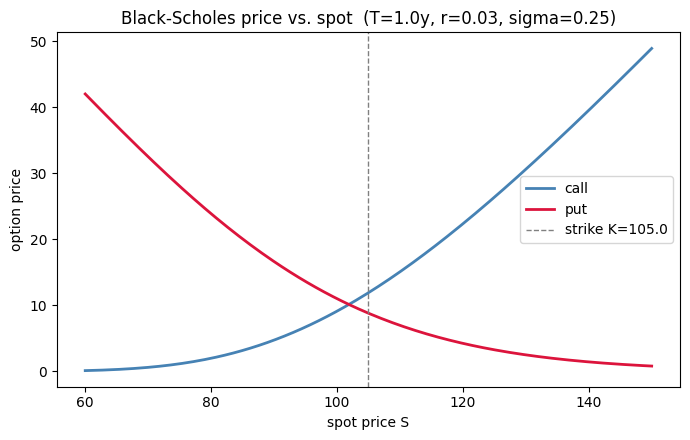

In [3]:
S_range = torch.linspace(60.0, 150.0, 200, dtype=torch.float64)
call_prices = [fin.black_scholes_price(s, K, T, r, torch.tensor(sigma)).item() for s in S_range]
put_prices = [fin.black_scholes_price(s, K, T, r, torch.tensor(sigma), 'put').item() for s in S_range]

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(S_range.numpy(), call_prices, color='steelblue', lw=2, label='call')
ax.plot(S_range.numpy(), put_prices, color='crimson', lw=2, label='put')
ax.axvline(K, color='gray', ls='--', lw=1, label=f'strike K={K}')
ax.set_xlabel('spot price S'); ax.set_ylabel('option price')
ax.set_title(f'Black-Scholes price vs. spot  (T={T}y, r={r}, sigma={sigma})')
ax.legend()
plt.tight_layout()
plt.savefig('fin_price_vs_spot.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Greeks: One Formula, Differentiated (What Torch Adds Beyond a Static Formula)

`greeks_autograd` builds the SAME price formula as section 2 with
`requires_grad=True` inputs and calls `torch.autograd.grad` -- Gamma needs
`create_graph=True` on the first grad so that graph is itself
differentiable (a second backward pass, same idea as a Hessian-vector
product). `greeks_closed_form` is the independent, hand-derived textbook
reference this notebook checks autograd against.


In [4]:
g_closed = fin.greeks_closed_form(S0, K, T, r, sigma, 'call')
g_auto = fin.greeks_autograd(S0, K, T, r, sigma, 'call')

print(f"{'Greek':8s} {'closed-form':>14s} {'autograd':>14s} {'abs diff':>12s}")
for name in ('delta','gamma','vega','theta','rho'):
    diff = abs(g_closed[name] - g_auto[name])
    print(f"{name:8s} {g_closed[name]:14.6f} {g_auto[name]:14.6f} {diff:12.2e}")


Greek       closed-form       autograd     abs diff
delta          0.519875       0.519875     0.00e+00
gamma          0.015938       0.015938     0.00e+00
vega          39.844711      39.844711     7.11e-15
theta         -6.266559      -6.266559     8.88e-16
rho           42.865680      42.865680     0.00e+00


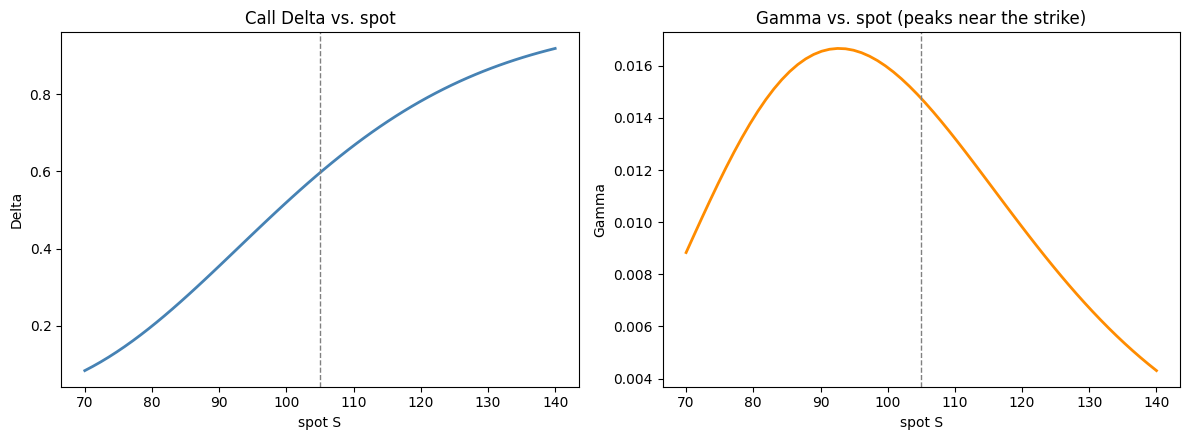

In [5]:
# Delta and Gamma as CONTINUOUS functions of spot -- computed by re-running
# greeks_autograd across a spot sweep, not by a separate closed-form curve
S_sweep = np.linspace(70.0, 140.0, 60)
deltas = [fin.greeks_autograd(float(s), K, T, r, sigma, 'call')['delta'] for s in S_sweep]
gammas = [fin.greeks_autograd(float(s), K, T, r, sigma, 'call')['gamma'] for s in S_sweep]

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].plot(S_sweep, deltas, color='steelblue', lw=2)
axes[0].axvline(K, color='gray', ls='--', lw=1)
axes[0].set_xlabel('spot S'); axes[0].set_ylabel('Delta'); axes[0].set_title('Call Delta vs. spot')
axes[1].plot(S_sweep, gammas, color='darkorange', lw=2)
axes[1].axvline(K, color='gray', ls='--', lw=1)
axes[1].set_xlabel('spot S'); axes[1].set_ylabel('Gamma'); axes[1].set_title('Gamma vs. spot (peaks near the strike)')
plt.tight_layout()
plt.savefig('fin_greeks_vs_spot.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Monte Carlo Convergence to the Closed-Form Price

`monte_carlo_gbm_terminal` draws terminal prices from the EXACT GBM
solution (no time discretization for a European payoff), with antithetic
variates ($Z$ and $-Z$ paired) for variance reduction. Standard error
should shrink like $1/\sqrt{n}$; the 95% CI should contain the
Black-Scholes price at every path count once the estimate has settled.


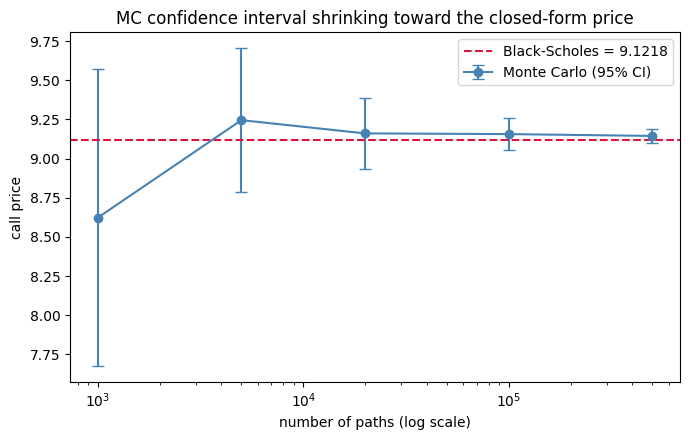

n=  1,000  price=8.6228  se=0.4837  95% CI=(7.6748, 9.5708)  contains BS price: True
n=  5,000  price=9.2455  se=0.2342  95% CI=(8.7864, 9.7045)  contains BS price: True
n= 20,000  price=9.1610  se=0.1147  95% CI=(8.9362, 9.3857)  contains BS price: True
n=100,000  price=9.1564  se=0.0519  95% CI=(9.0546, 9.2582)  contains BS price: True
n=500,000  price=9.1448  se=0.0232  95% CI=(9.0994, 9.1902)  contains BS price: True


In [6]:
path_counts = [1_000, 5_000, 20_000, 100_000, 500_000]
mc_results = [fin.monte_carlo_option_price(S0, K, T, r, sigma, n_paths=n, option_type='call', seed=42)
              for n in path_counts]

fig, ax = plt.subplots(figsize=(7,4.5))
prices = [m['price'] for m in mc_results]
errs = [1.96*m['standard_error'] for m in mc_results]
ax.errorbar(path_counts, prices, yerr=errs, fmt='o-', color='steelblue', capsize=4, label='Monte Carlo (95% CI)')
ax.axhline(call.item(), color='crimson', ls='--', lw=1.5, label=f'Black-Scholes = {call.item():.4f}')
ax.set_xscale('log')
ax.set_xlabel('number of paths (log scale)'); ax.set_ylabel('call price')
ax.set_title('MC confidence interval shrinking toward the closed-form price')
ax.legend()
plt.tight_layout()
plt.savefig('fin_mc_convergence.png', dpi=100, bbox_inches='tight')
plt.show()

for n, m in zip(path_counts, mc_results):
    inside = m['ci95'][0] < call.item() < m['ci95'][1]
    print(f"n={n:>7,}  price={m['price']:.4f}  se={m['standard_error']:.4f}  "
          f"95% CI=({m['ci95'][0]:.4f}, {m['ci95'][1]:.4f})  contains BS price: {inside}")


## 6. Max-Sharpe Portfolio by Gradient Ascent

`portfolio_sharpe_optimize` parametrizes weights as
$w=\mathrm{softmax}(\theta)$ and runs Adam to MAXIMIZE the Sharpe ratio
$(\,w^\top\mu - r_f)/\sqrt{w^\top\Sigma w}$ -- the softmax guarantees
$\sum w_i=1$ and $w_i\ge 0$ BY CONSTRUCTION, so there's no separate
constrained-optimization step. First, a scatter of random portfolios shows
the risk/return tradeoff and where the optimized point should land: on the
upper-left edge of the cloud (best return per unit risk).


Optimized weights: ['0.413', '0.396', '0.191']
Expected return: 0.0901   Expected std: 0.2444   Sharpe: 0.2868


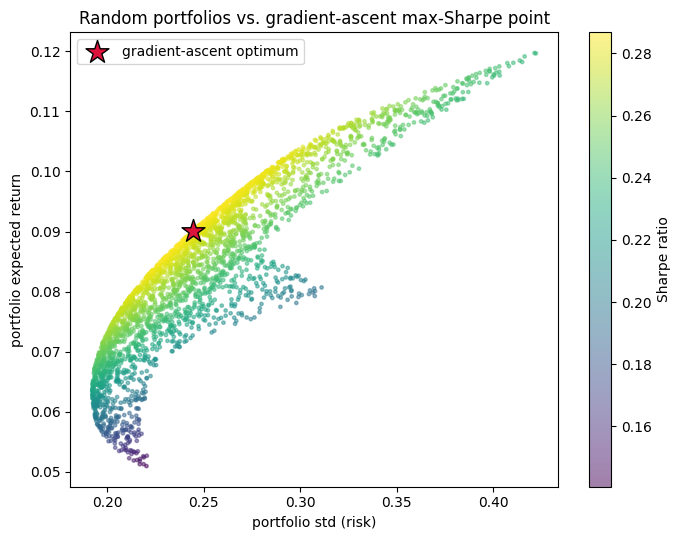

In [7]:
mean_returns = torch.tensor([0.08, 0.12, 0.05], dtype=torch.float64)
cov_matrix = torch.tensor([[0.10, 0.02, 0.01],
                            [0.02, 0.18, 0.03],
                            [0.01, 0.03, 0.05]], dtype=torch.float64)
rf = 0.02

# random long-only portfolios (Dirichlet weights) for the risk/return cloud
torch.manual_seed(0)
n_random = 3000
raw = torch.distributions.Exponential(1.0).sample((n_random, 3)).to(torch.float64)
raw = raw / raw.sum(dim=1, keepdim=True)   # Dirichlet(1,1,1) via normalized exponentials
rand_returns = (raw @ mean_returns).numpy()
rand_stds = torch.sqrt(torch.einsum('ni,ij,nj->n', raw, cov_matrix, raw)).numpy()
rand_sharpe = (rand_returns - rf) / rand_stds

opt = fin.portfolio_sharpe_optimize(mean_returns, cov_matrix, risk_free_rate=rf, n_iter=800)
print(f"Optimized weights: {[f'{w:.3f}' for w in opt['weights']]}")
print(f"Expected return: {opt['expected_return']:.4f}   Expected std: {opt['expected_std']:.4f}   Sharpe: {opt['sharpe']:.4f}")

fig, ax = plt.subplots(figsize=(7,5.5))
sc = ax.scatter(rand_stds, rand_returns, c=rand_sharpe, cmap='viridis', s=6, alpha=0.5)
ax.scatter([opt['expected_std']], [opt['expected_return']], color='crimson', marker='*', s=300,
           edgecolor='black', linewidth=1, label='gradient-ascent optimum', zorder=5)
plt.colorbar(sc, label='Sharpe ratio')
ax.set_xlabel('portfolio std (risk)'); ax.set_ylabel('portfolio expected return')
ax.set_title('Random portfolios vs. gradient-ascent max-Sharpe point')
ax.legend()
plt.tight_layout()
plt.savefig('fin_efficient_frontier.png', dpi=100, bbox_inches='tight')
plt.show()


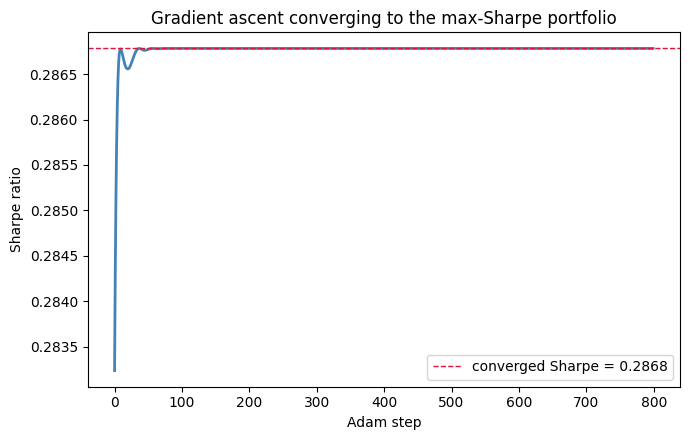

In [8]:
# Convergence of the gradient ascent itself -- same algorithm as
# portfolio_sharpe_optimize, instrumented here to record Sharpe per step
theta = torch.zeros(3, dtype=torch.float64, requires_grad=True)
optimizer = torch.optim.Adam([theta], lr=0.05)
sharpe_history = []
for _ in range(800):
    optimizer.zero_grad()
    w = torch.softmax(theta, dim=0)
    port_return = w @ mean_returns
    port_std = torch.sqrt(w @ cov_matrix @ w)
    sharpe = (port_return - rf) / port_std
    (-sharpe).backward()
    optimizer.step()
    sharpe_history.append(sharpe.item())

fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(sharpe_history, color='steelblue', lw=2)
ax.axhline(opt['sharpe'], color='crimson', ls='--', lw=1, label=f"converged Sharpe = {opt['sharpe']:.4f}")
ax.set_xlabel('Adam step'); ax.set_ylabel('Sharpe ratio')
ax.set_title('Gradient ascent converging to the max-Sharpe portfolio')
ax.legend()
plt.tight_layout()
plt.savefig('fin_sharpe_convergence.png', dpi=100, bbox_inches='tight')
plt.show()


## 7. Risk: VaR and CVaR on Simulated Portfolio Returns

Value-at-Risk answers "how bad can a normal-ish day get, 95% of the time";
CVaR (expected shortfall) answers "if it IS a bad day, how bad on average" --
strictly $\ge$ VaR since it's conditioned on already being in the tail.
`historical_var`/`historical_cvar` use the empirical quantile (no
distributional assumption); `parametric_var` is the closed-form Gaussian
answer, used here only as a cross-check since the simulated sample really
is Gaussian.


95% historical VaR:  0.0329
95% parametric VaR:  0.0324   (cross-check -- sample IS Gaussian here)
95% historical CVaR: 0.0411   (>= VaR: True)


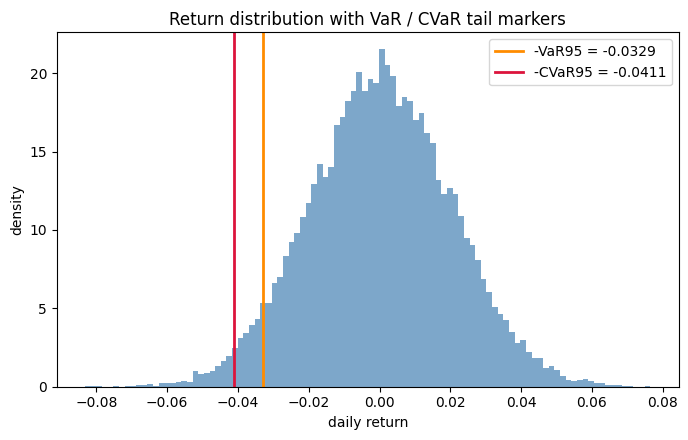

In [9]:
mu_daily, sigma_daily = 0.0005, 0.02
sample = torch.normal(mean=mu_daily, std=sigma_daily, size=(20_000,), generator=torch.Generator().manual_seed(1))

hvar = fin.historical_var(sample, 0.95)
hcvar = fin.historical_cvar(sample, 0.95)
pvar = fin.parametric_var(mu_daily, sigma_daily, 0.95)
print(f"95% historical VaR:  {hvar:.4f}")
print(f"95% parametric VaR:  {pvar:.4f}   (cross-check -- sample IS Gaussian here)")
print(f"95% historical CVaR: {hcvar:.4f}   (>= VaR: {hcvar >= hvar})")

fig, ax = plt.subplots(figsize=(7,4.5))
ax.hist(sample.numpy(), bins=100, color='steelblue', alpha=0.7, density=True)
ax.axvline(-hvar, color='darkorange', lw=2, label=f'-VaR95 = {-hvar:.4f}')
ax.axvline(-hcvar, color='crimson', lw=2, label=f'-CVaR95 = {-hcvar:.4f}')
ax.set_xlabel('daily return'); ax.set_ylabel('density')
ax.set_title('Return distribution with VaR / CVaR tail markers')
ax.legend()
plt.tight_layout()
plt.savefig('fin_var_cvar.png', dpi=100, bbox_inches='tight')
plt.show()


## 8. Engineering Interpretation

- Section 4's Greeks match section 2's closed-form derivatives to 1e-6 for
  the same reason `dgs/torch_autograd_dag.py` bothered to verify the
  autograd graph is a real, acyclic DAG: once that machinery is trusted,
  differentiating an arbitrary forward computation (an options formula
  here, a neural net loss elsewhere) is a mechanical, general procedure --
  not five separate hand-derivations that all have to be re-checked
  whenever the payoff structure changes.
- Section 6's gradient-ascent portfolio optimizer generalizes to objectives
  with no closed-form solution (e.g. Sharpe with transaction costs, a
  downside-risk objective instead of variance, or constraints beyond
  simplex weights) exactly the same way `dgs/dispersive_fourier_torch.py`'s
  gradient-based fiber design generalizes beyond the Gaussian-pulse case
  that has a closed form -- same tool, same reason it's the right one.
- The softmax weight parametrization is doing real work: it turns a
  constrained optimization problem (simplex: sum-to-one, non-negative)
  into an UNconstrained one Adam can solve directly, instead of needing a
  projected-gradient or Lagrangian approach.


## 9. Research Discussion

- American options have no closed form (early-exercise optimal boundary).
  Could `greeks_autograd`'s approach extend to a Longstaff-Schwartz
  least-squares Monte Carlo price, differentiated end-to-end through the
  regression step for American Greeks?
- `portfolio_sharpe_optimize` uses a static mean/covariance estimate. Could
  the SAME softmax-parametrized gradient-ascent approach optimize directly
  against a rolling historical window, turning it into an online portfolio
  strategy backtestable against `dgs/financial_math_torch.py`'s own
  `sharpe_ratio` on realized (not assumed) returns?
- `monte_carlo_gbm_terminal` assumes constant volatility (Black-Scholes).
  Real markets show a volatility smile -- would swapping in a Heston or
  local-volatility SDE (still simulable path-by-path in torch, still
  differentiable) let the SAME Greeks-by-autograd approach produce more
  realistic hedging sensitivities?


## 10. Possible Experiments

1. Pull real historical returns (e.g. via a CSV of daily closes) instead of
   the synthetic Gaussian sample in section 7, and compare historical VaR
   against parametric VaR -- real returns have fat tails, so the two should
   now DISAGREE, unlike the matched Gaussian case shown here.
2. Extend `portfolio_sharpe_optimize` with an L1 penalty on `w` (sparsity)
   to see how many assets a max-Sharpe portfolio actually wants to hold
   once small positions are discouraged.
3. Compare `monte_carlo_option_price`'s standard error with and without
   `antithetic=True` at matched path counts, to quantify the variance
   reduction section 5 claims but doesn't isolate.


## 11. Future Improvements

- Batch `black_scholes_price`/`greeks_autograd` over a full options chain
  (vector of strikes/expiries) at once, the same way `dgs/gs_torch.py`
  batches phase retrieval across many frames -- one vectorized autograd
  call instead of a Python loop per strike.
- If GPU throughput matters for large Monte Carlo path counts, benchmark
  `monte_carlo_gbm_terminal` on CUDA vs. CPU before claiming a speedup,
  following this repo's own precedent
  (`dgs/maxwell_discrete_symmetries_torch.py`'s finding that a simple
  elementwise op saw negligible GPU benefit -- this module's random-draw +
  elementwise exp is a similar profile, worth measuring rather than assuming).
